# EDA Notebook

## 1. Importar librerías necesarias
Importar pandas, numpy, matplotlib y seaborn para el análisis y visualización de datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium as fl
import nltk as nt


## 2. Cargar el archivo CSV
Solicitar al usuario la ruta del archivo .csv y cargarlo en un DataFrame de pandas.

In [2]:
import os

# Change this path to point to your data file
file_path = 'data/raw/Hotel_Reviews.csv'

possible_paths = [
	file_path,
	'Hotel_Reviews.csv',
	'data/Hotel_Reviews.csv',
	'../data/raw/Hotel_Reviews.csv',
	'./data/raw/Hotel_Reviews.csv',
]

for path in possible_paths:
	if os.path.exists(path):
		file_path = path
		break

if not os.path.exists(file_path):
	raise FileNotFoundError(
		f"File not found: {file_path}. "
		"Please verify the dataset location or move the CSV to one of the expected paths."
	)

df = pd.read_csv(file_path)

## 3. Visualizar las primeras filas del dataset
Mostrar las primeras filas del DataFrame usando head() para obtener una vista general de los datos.

In [3]:
df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


## 4. Explorar información general del dataset
Utilizar info() y shape para mostrar información sobre el número de filas, columnas y tipos de datos.

In [4]:
df.info()
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

<class 'pandas.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  str    
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  str    
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  str    
 5   Reviewer_Nationality                        515738 non-null  str    
 6   Negative_Review                             515738 non-null  str    
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738 non-null  str    
 10  Review_

## 5. Describir variables numéricas y categóricas
Usar describe() para variables numéricas y value_counts() para variables categóricas.

In [5]:
# Numerical variables
print(df.describe())
#obtenemos las 20 nacionalidades que más comentan
nationalities_most_commented = df['Reviewer_Nationality'].value_counts().head(20)
#display(nationalities_most_commented)

       Additional_Number_of_Scoring  Average_Score  \
count                 515738.000000  515738.000000   
mean                     498.081836       8.397487   
std                      500.538467       0.548048   
min                        1.000000       5.200000   
25%                      169.000000       8.100000   
50%                      341.000000       8.400000   
75%                      660.000000       8.800000   
max                     2682.000000       9.800000   

       Review_Total_Negative_Word_Counts  Total_Number_of_Reviews  \
count                      515738.000000            515738.000000   
mean                           18.539450              2743.743944   
std                            29.690831              2317.464868   
min                             0.000000                43.000000   
25%                             2.000000              1161.000000   
50%                             9.000000              2134.000000   
75%                           

## 6. Visualizar valores nulos y duplicados
Identificar y visualizar la cantidad de valores nulos y filas duplicadas en el dataset.

In [6]:
# Null values
print("VALORES NULOS: \n",df.isnull().sum())

# Duplicated rows
print("REGISTROS DUPLICADOS ",df.duplicated().sum())

VALORES NULOS: 
 Hotel_Address                                    0
Additional_Number_of_Scoring                     0
Review_Date                                      0
Average_Score                                    0
Hotel_Name                                       0
Reviewer_Nationality                             0
Negative_Review                                  0
Review_Total_Negative_Word_Counts                0
Total_Number_of_Reviews                          0
Positive_Review                                  0
Review_Total_Positive_Word_Counts                0
Total_Number_of_Reviews_Reviewer_Has_Given       0
Reviewer_Score                                   0
Tags                                             0
days_since_review                                0
lat                                           3268
lng                                           3268
dtype: int64
REGISTROS DUPLICADOS  526


## 7. Análisis univariado de variables numéricas
Realizar histogramas y boxplots para analizar la distribución de las variables numéricas.

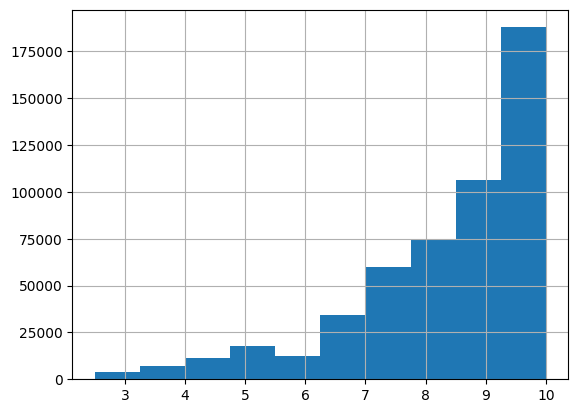

In [7]:
# Histogram for a numerical variable. Agrupa los valores numéricos en barras o contenedores para mostrar con qué frecuencia aparece cada rango de números  
# df['numeric_column'].hist()

df['Reviewer_Score'].hist() 
plt.show()

# Boxplot
# df.boxplot(column='numeric_column')
# plt.show()

Aquí estamos viendo que las quejas son eventos menos comunes pero más drásticos.

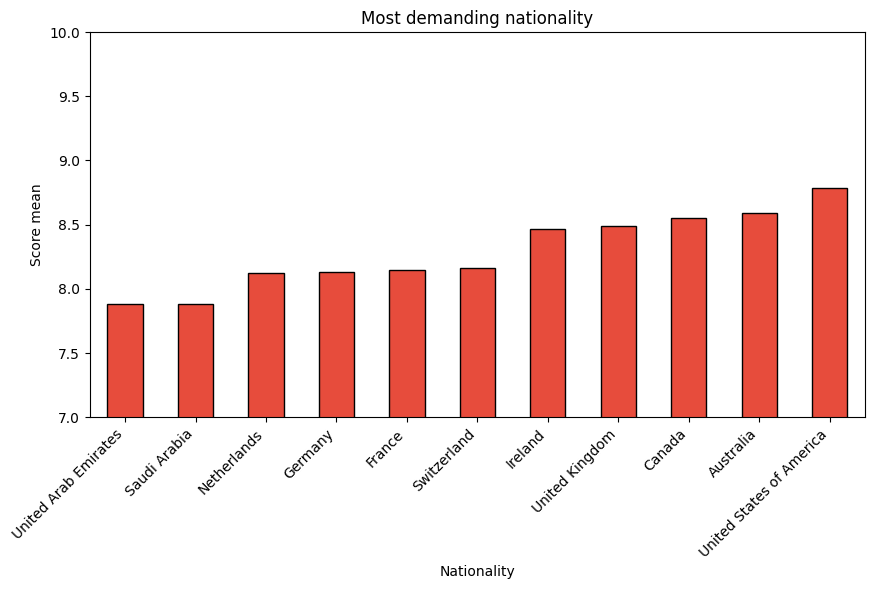

In [8]:
#Existe una relacion entre la nacionalidad del huesped y la nota que le pone al hotel?

#1.Las nacionalidades mas presentes en el dataset
df['Reviewer_Nationality'] = df['Reviewer_Nationality'].str.strip() #primero limpiamos los espacios en blanco
top_presents_nationalities = df['Reviewer_Nationality'].value_counts().head(11).index

#2.Filtramos el dataframe para quedarnos solamente con esas nacionalidades
df_top_countries = df[df['Reviewer_Nationality'].isin(top_presents_nationalities)]
most_negative_review = df_top_countries.groupby('Reviewer_Nationality')['Reviewer_Score'].mean().sort_values()#ordenamos por media

#3.Levantamos el grafico con matplotlib
plt.figure(figsize=(10, 5))
most_negative_review.plot(kind='bar', color='#e74c3c', edgecolor='black')

#4. Personalizamos el grafico
plt.title('Most demanding nationality')
plt.xlabel('Nationality')
plt.ylabel('Score mean')

plt.ylim(7, 10) #zoom para notar mas la diferencia
plt.xticks(rotation=45, ha='right') #giramos los nombres de los paises para que no se pisen
plt.tight_layout

plt.show() 

Según el gráfico, los turistas de Emiratos Árabes Unidos ponen las notas más bajas, mientras que los estadounidenses ponen las notas más altas. Para comprender estos resultados, es importante tener en cuenta que en ciudades como Dubai, los hoteles de lujo cumplen con unos estándares que probablemente estén por encima del lujo clásico europeo, por lo que los turistas emiratíes tenderán a ser más exigentes. Es más, los segundos más exigentes son los turistas saudíes, por lo que de esta manera se puede reafirmar la exigencia del lujo de Oriente Medio.

Descubramos por qué se quejan los turistas de Emiratos Árabes Unidos:

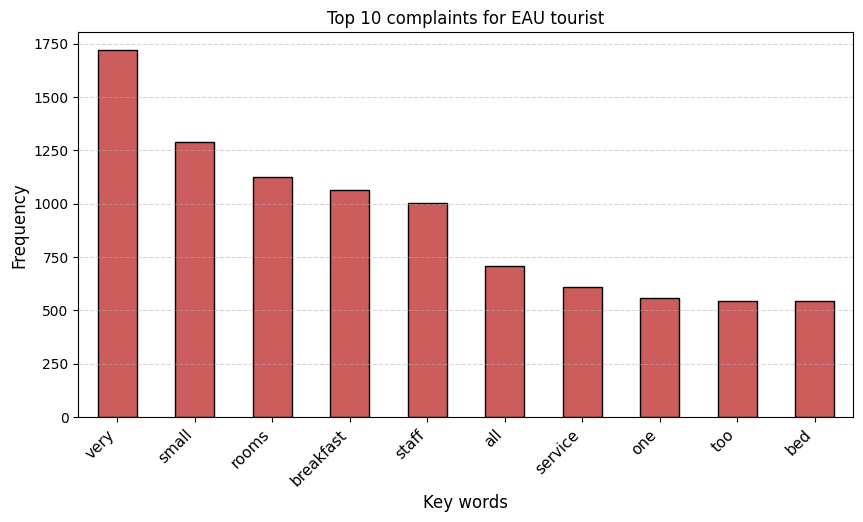

In [6]:
import re

df['Reviewer_Nationality'] = df['Reviewer_Nationality'].str.strip()

# 2. Creamos el filtro de los emiratíes AQUÍ MISMO para asegurar que tenga datos
df_eau = df[df['Reviewer_Nationality'] == 'United Arab Emirates']

#filtramos el dataframe para que solamente nos queden las filas de Emiratos.
df_dates = pd.to_datetime(df['Review_Date'])
complaint = " ".join(df_eau['Negative_Review'].astype(str).tolist()).lower() #bag of words. Unimos todas las palabras, y no separamos por filas
#Limpieza rapida de palabras, romper el texto en palabras sueltas
words = re.findall(r'\b[a-z]{3,}\b', complaint)
#palabras que no queremos
stopwords = {
    'the', 'and', 'was', 'not', 'for', 'with', 'but', 'room', 'hotel', 'nothing',
    'are','they', 'have', 'there', 'you', 'that', 'this', 'were', 'had', 'from', 'our', 'no', 'negative' 
}

#filtramos para quitar las palabras vacias de la linea
important_words = [p for p in words if p not in stopwords]

#cuales son las palabras que mas se repiten
top_complaint = pd.Series(important_words).value_counts().head(10)

plt.figure(figsize=(10, 5))

top_complaint.plot(kind='bar', color='indianred', edgecolor='black')
plt.title('Top 10 complaints for EAU tourist')
plt.xlabel('Key words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Viendo las palabras que más se repiten en las reseñas negativas de los turistas de Emiratos Árabes Unidos, vemos que se repiten las palabras, entre otras: SMALL, ROOMS, BREAKFAST o SERVICE. Se puede entender que los clientes encuentran problemas en el tamaño de las habitaciones, el desayuno e incluso en el servicio. Negative hace referencia a cuando los turistas no dejan ninguna reseña.

ESTACIONALIDAD DE LAS QUEJAS.
Aquí queremos ver si los clientes se quejan más en verano o en invierno, para poder analizar qué falla en los hoteles (problemas con el aire acondicionado o la calefacción, trabajadores saturados o sobrepasados por carga de trabajo excesiva)

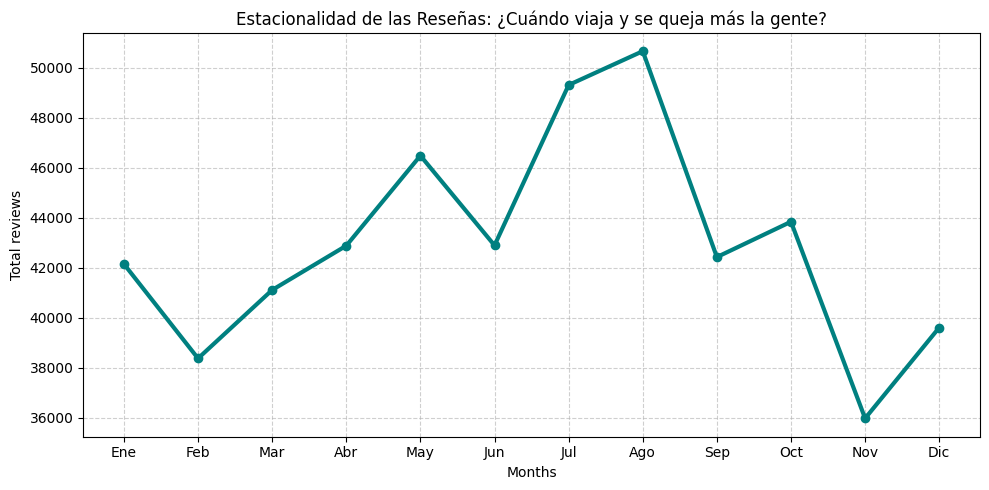

In [10]:
# 1. Convertir la columna de fechas a formato DateTime real de Pandas
df['Review_Date'] = pd.to_datetime(df['Review_Date'])

# 2. Extraer el número de mes (1 = Enero, 12 = Diciembre)
df['Month'] = df['Review_Date'].dt.month

# 3. Contar cuántas reviews (quejas) hay en cada mes del año y ordenarlos cronológicamente
month_complaints = df['Month'].value_counts().sort_index()

# 4. Mapear los números a nombres de meses cortos para que el gráfico quede precioso
months = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
month_complaints.index = months

# 5. Dibujar el gráfico de líneas (ideal para ver el paso del tiempo o meses)
plt.figure(figsize=(10, 5))
plt.plot(month_complaints.index, month_complaints.values, marker='o', color='teal', linewidth=3)

# 6. Personalizar la estética
plt.title('Estacionalidad de las Reseñas: ¿Cuándo viaja y se queja más la gente?')
plt.xlabel('Months')
plt.ylabel('Total reviews')
plt.grid(True, linestyle='--', alpha=0.6) # Añadimos cuadrícula para ver mejor los picos
plt.tight_layout()

# Mostrar el gráfico
plt.show()

Ahora, obtendremos las quejas que se realizaron durante esa época del año, para entender de qué se quejaban los clientes durante los meses con más quejas (como puede verse, julio y agosto) y podamos comprender mejor el contexto.

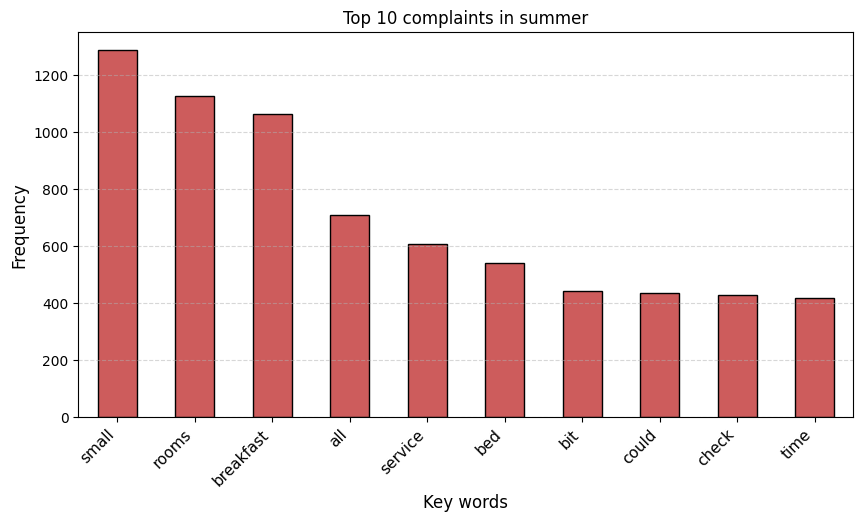

In [25]:
df['Review_Date'] = pd.to_datetime(df['Review_Date'])
df['Month'] = df['Review_Date'].dt.month #creamos columna nueva con solamente el mes

df_summer = df[df['Month'].isin([7,8])]#nos aseguramos de solo incluir los meses de julio y agosto

complaint_summer = " ".join(df_summer['Negative_Review'].astype(str).tolist()).lower() #juntamos todas las quejas en un bloque
words_summer = re.findall(r'\b[a-z]{3,}\b', complaint_summer) #aplicamos el regex

#palabras que no nos interesan
stopwords = {
        'the', 'and', 'was', 'not', 'for', 'with', 'but', 'room', 'hotel', 'nothing','when',
        'they', 'have', 'there', 'you', 'that', 'this', 'were', 'had', 'from', 'our', 'too'
        'all', 'very', 'one', 'would', 'about', 'good', 'get', 'been', 'location', 'staff', 'are', 'no', 'negative',
        'too', 'like', 'which', 'out', 'bad', 'more'
    }

#filtramos para quitar las palabras vacias de la linea
important_words_summer = [p for p in words if p not in stopwords]

#cuales son las palabras que mas se repiten
top_complaint_summer = pd.Series(important_words_summer).value_counts().head(10)

#creamos el grafico
plt.figure(figsize=(10, 5))
top_complaint_summer.plot(kind='bar', color='indianred', edgecolor='black')
plt.title('Top 10 complaints in summer')
plt.xlabel('Key words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

AQUI FALTA LA CONCLUSION

## 8. Análisis bivariado entre variables
Explorar relaciones entre variables numéricas y categóricas mediante scatterplots y tablas cruzadas.

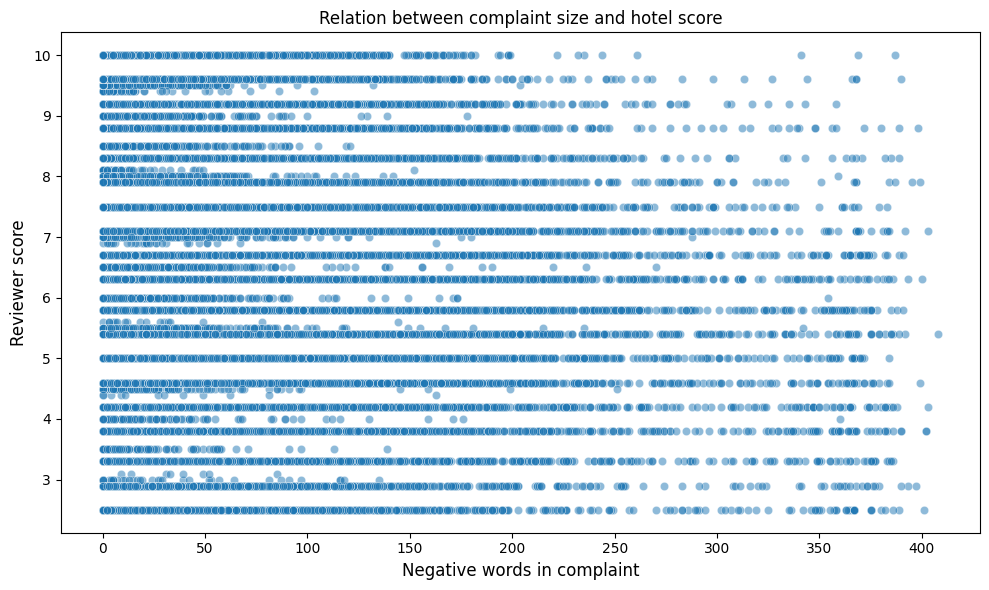

In [ ]:
# Scatterplot. Longitud de la queja y la puntuacion del hotel. Veamos si hay algun tipo de relacion 

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Review_Total_Negative_Word_Counts', y='Reviewer_Score', alpha=0.5)

plt.title('Relation between complaint size and hotel score', fontsize=12)
plt.xlabel('Negative words in complaints', fontsize=12)
plt.ylabel('Reviewer score', fontsize=12)

plt.tight_layout()
plt.show()


Análisis del scatterplot: este gráfico demuestra que hay una relación directa entre la puntuación que el cliente da al hotel y el número de palabras que contiene una reseña. En el lado izquierdo del gráfico (desde las 0 y 100 palabras) puede observarse que las líneas y los puntos son de un color intenso y sólido. Esto significa que, por lo general, las reseñas son cortas. Puede observarse este fenómeno tanto en las reseñas positivas como en las negativas. Podría establecerse que es el comportamiento estándar. Sin embargo, según nos vamos desplazando a la derecha, o sea, hacia reseñas con mayor número de palabras, vemos que en la parte superior (donde las reseñas son positivas) se esclarecen los puntos y podemos ver huecos en blanco. Esto significa que una persona satisfecha, que ha puntuado al hotel con más de un siete, no escribe reseñas tan largas. En contraposición, sí podemos ver que, cuanta más baja es la puntuación, más tiempo pasa el cliente escribiendo su reseña negativa. Podemos concluir que, cuanto más negativa es la reseña, mayor es la necesidad que tiene el cliente de explicar su experiencia. Dedica más tiempo a señalar lo que está mal.

## 9. Visualización de correlaciones
Calcular y visualizar la matriz de correlación entre variables numéricas usando un heatmap.

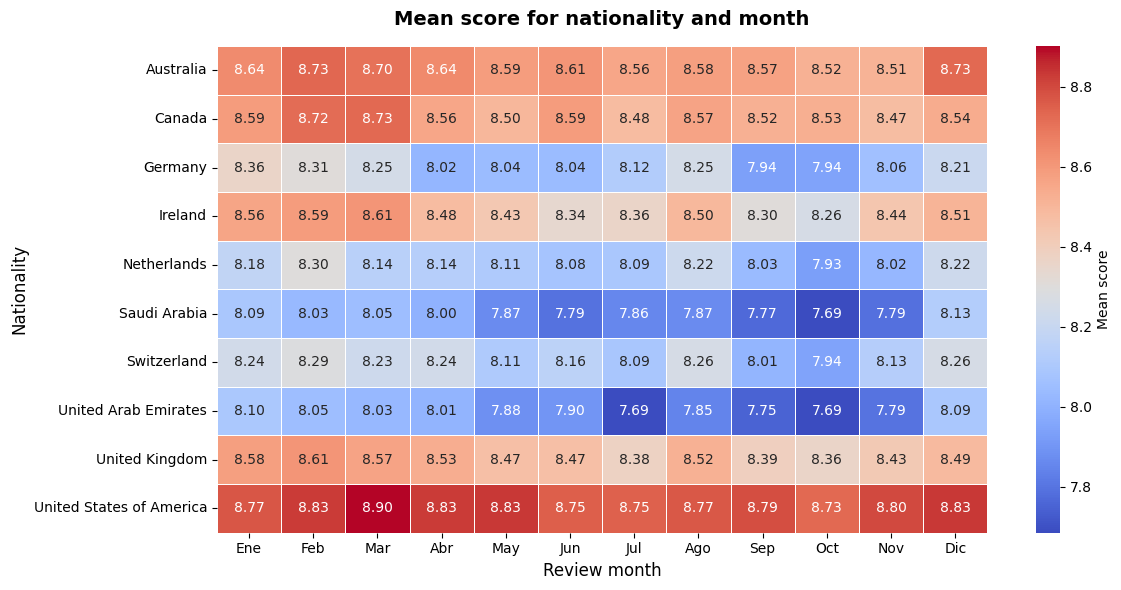

In [30]:
df['Review_Date'] = pd.to_datetime(df['Review_Date'])
df['Month'] = df['Review_Date'].dt.month

top_countries = df['Reviewer_Nationality'].value_counts().head(10).index
df_filtered = df[df['Reviewer_Nationality'].isin(top_countries)]
#necesitamos un pivot_table para calcular la puntuacion media, calculamos la media para ver los puntos negros de insatisfaccion
heat_matrix = df_filtered.pivot_table(
    values='Reviewer_Score', 
    index='Reviewer_Nationality', 
    columns='Month', 
    aggfunc='mean'
)

months_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'] #cambiar al ingles
heat_matrix.columns = months_names
#creamos el mapa
plt.figure(figsize=(12,6))

sns.heatmap(
    heat_matrix, 
    cmap='coolwarm', 
    annot=True, 
    fmt=".2f", 
    linewidths=0.5,
    cbar_kws={'label': 'Mean score'}
)
#lo personalizamos
plt.title('Mean score for nationality and month', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Review month', fontsize=12)
plt.ylabel('Nationality', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


Este gráfico representa la media de las puntuaciones de los 10 países que más reviews dejan. Podemos ver que la puntuación más alta la dejan los estadounidenses, teniendo los picos más altos en los meses de febrero, marzo, abril, mayo y diciembre. También podemos encontrar notas superiores a la media en las reviews de australianos y canadiense, y en menor medida, irlandeses e ingleses. Sin embargo, en el centro del mapa podemos encontrar nacionalidades como la emiratí, la suiza, la saudita y la neerlandesa. Para ellos, la experiencia en estos hoteles es peor, y se ve claramente reflejado en la nota media de la review. Podemos encontrar que los puntos más bajos son los meses de verano y en octubre, precisamente cuando acaba la temporada alta y se reduce al personal trabajador de los hoteles. La puntuación tan baja de este grupo puede deberse a que los hoteles estén saturados, la atención del personal baja significativamente, y la infraestructura se resienten y los clientes consideren que el precio pagado es excesivo por lo que se oferta.